In [1]:
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import LabelEncoder, label_binarize
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('F:/mental health projct of jp/suicide paper/dataset/2_types_filtered_features_3lakh.csv')
df.head()

,text,Label,filtered_text_eng,tokenized_text,Preprocessed_Text,filtered_tokenized_words
0,"I'm done with it all. Any tips?First of all, i...",2,done with it Any of if going to comment get or...,"['done', 'go', 'comment', 'get', 'plea', 'unde...",done go comment get plea understand want hear ...,"['kill', 'pain', 'sorri', 'hate']"
1,i 20m was a problem child when grow up i frequ...,1,i was a problem child when grow up i frequent ...,"['problem', 'child', 'grow', 'frequent', 'got'...",problem child grow frequent got troubl junior ...,"['ill', 'awkward', 'steal', 'silenc', 'wrong',..."
2,I officially hate my school We have to start p...,0,I officially hate my school We have to start o...,"['offici', 'hate', 'school', 'start', 'enter',...",offici hate school start enter caus fix,"['offici', 'hate', 'school', 'start', 'enter',..."
3,but onc again depress love to take that from m...,1,but onc again depress love to take that from m...,"['onc', 'depress', 'love', 'take', 'angri', 'w...",onc depress love take angri want cri wont come...,"['cri', 'angri', 'damn', 'tire', 'depress']"
4,"Starting today, I'm going to attempt to fix my...",0,Starting going to attempt to fix my sleep sche...,"['start', 'go', 'attempt', 'fix', 'sleep', 'sc...",start go attempt fix sleep schedul school coup...,"['start', 'go', 'attempt', 'fix', 'sleep', 'sc..."


In [3]:
df1 = pd.read_csv('F:/mental health projct of jp/suicide paper/dataset/2_types_all_features.csv')
df1.head()

,0,1,2,3,4,5,6,7,8,9,...,2781,2782,2783,2784,2785,2786,2787,2788,2789,2790
0,-0.311691,0.207526,0.294796,-0.370256,-0.463946,0.004523,0.103642,0.023245,-0.273210,-0.043930,...,1.174970,-0.131030,0.581713,1.317829,0.545300,-4.912285,2.002302,-2.429308,2.313626,0.068317
1,-0.314458,0.200302,0.248307,-0.337924,-0.354438,-0.029178,0.120759,0.028209,-0.381361,-0.010982,...,-0.170022,-1.057125,0.506787,0.481089,-0.443753,-1.015673,0.295432,-1.521313,-0.511028,-0.270724
2,-0.258834,0.199409,0.255281,-0.329083,-0.421285,-0.008494,0.122459,0.000529,-0.345936,-0.007731,...,-0.475023,-2.049421,-2.095686,-2.270150,2.747774,-4.004583,-1.818186,-3.040991,-0.021306,1.718746
3,-0.348873,0.164237,0.313819,-0.395596,-0.340182,-0.008542,0.077583,-0.002947,-0.369009,0.005620,...,1.116820,0.496508,2.048395,-0.856290,0.582634,-1.573221,0.650254,-1.483610,0.080408,-0.893238
4,-0.258569,0.201524,0.242732,-0.321395,-0.432100,-0.044947,0.111697,0.009705,-0.350573,-0.033735,...,-0.861691,-1.552952,-0.070507,-2.612564,0.754670,-5.594344,3.663493,-0.440785,1.437596,-0.616004


In [4]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df1)

In [5]:
# Apply PCA
pca = PCA(n_components=100, random_state=42)
X = pca.fit_transform(X_scaled)

In [6]:
y = df['Label'].values

In [7]:
# Define the path to the directory
save_directory = "F:/mental health projct of jp/suicide paper/plot"

# Ensure the directory exists
if not os.path.exists(save_directory):
    os.makedirs(save_directory)

In [8]:
# Split the data into training, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, shuffle=True)

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import os

# Define the SAINT model components
class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super(SelfAttention, self).__init__()
        self.embed_dim = embed_dim
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)
        scores = torch.matmul(q, k.transpose(-2, -1)) / np.sqrt(self.embed_dim)
        attention = self.softmax(scores)
        return torch.matmul(attention, v)

class SAINT(nn.Module):
    def __init__(self, input_dim, output_dim, embed_dim=64):
        super(SAINT, self).__init__()
        self.embed_dim = embed_dim
        self.fc1 = nn.Linear(input_dim, embed_dim)
        self.attention = SelfAttention(embed_dim)
        self.fc2 = nn.Linear(embed_dim, embed_dim)
        self.fc3 = nn.Linear(embed_dim, output_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.attention(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Initialize datasets and loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model, loss function, optimizer, and scheduler
input_dim = X_train.shape[1]
output_dim = len(np.unique(y_train))
model = SAINT(input_dim, output_dim, embed_dim=64)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)

# Training loop with early stopping
epochs = 50
patience = 10
best_val_loss = float('inf')
early_stop_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0
    correct_train_predictions = 0
    total_train_samples = 0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train_predictions += (predicted == batch_y).sum().item()
        total_train_samples += batch_y.size(0)

    avg_train_loss = epoch_train_loss / len(train_loader)
    avg_train_accuracy = correct_train_predictions / total_train_samples
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_accuracy)

    # Validation phase
    model.eval()
    epoch_val_loss = 0
    correct_val_predictions = 0
    total_val_samples = 0

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            epoch_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_val_predictions += (predicted == batch_y).sum().item()
            total_val_samples += batch_y.size(0)

    avg_val_loss = epoch_val_loss / len(val_loader)
    avg_val_accuracy = correct_val_predictions / total_val_samples
    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}, "
          f"Train Loss: {avg_train_loss:.4f}, Train Accuracy: {avg_train_accuracy:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Accuracy: {avg_val_accuracy:.4f}")

    scheduler.step(avg_val_loss)

    # Early Stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered")
            break




F:\mental health projct of jp\Hilano\.venv\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 1/50, Train Loss: 0.2682, Train Accuracy: 0.8909, Val Loss: 0.2583, Val Accuracy: 0.8964
Epoch 2/50, Train Loss: 0.2508, Train Accuracy: 0.9019, Val Loss: 0.2507, Val Accuracy: 0.9005
Epoch 3/50, Train Loss: 0.2533, Train Accuracy: 0.9018, Val Loss: 0.2595, Val Accuracy: 0.9004
Epoch 4/50, Train Loss: 0.2655, Train Accuracy: 0.8983, Val Loss: 0.2558, Val Accuracy: 0.9036
Epoch 5/50, Train Loss: 0.2645, Train Accuracy: 0.8995, Val Loss: 0.2579, Val Accuracy: 0.9033
Epoch 6/50, Train Loss: 0.2688, Train Accuracy: 0.8959, Val Loss: 0.2544, Val Accuracy: 0.8981
Epoch 7/50, Train Loss: 0.2736, Train Accuracy: 0.8967, Val Loss: 0.2804, Val Accuracy: 0.8866
Epoch 8/50, Train Loss: 0.2764, Train Accuracy: 0.8944, Val Loss: 0.2645, Val Accuracy: 0.8954
Epoch 9/50, Train Loss: 0.2570, Train Accuracy: 0.8972, Val Loss: 0.2509, Val Accuracy: 0.8967
Epoch 10/50, Train Loss: 0.2479, Train Accuracy: 0.8998, Val Loss: 0.2421, Val Accuracy: 0.8989
Epoch 11/50, Train Loss: 0.2403, Train Accuracy: 

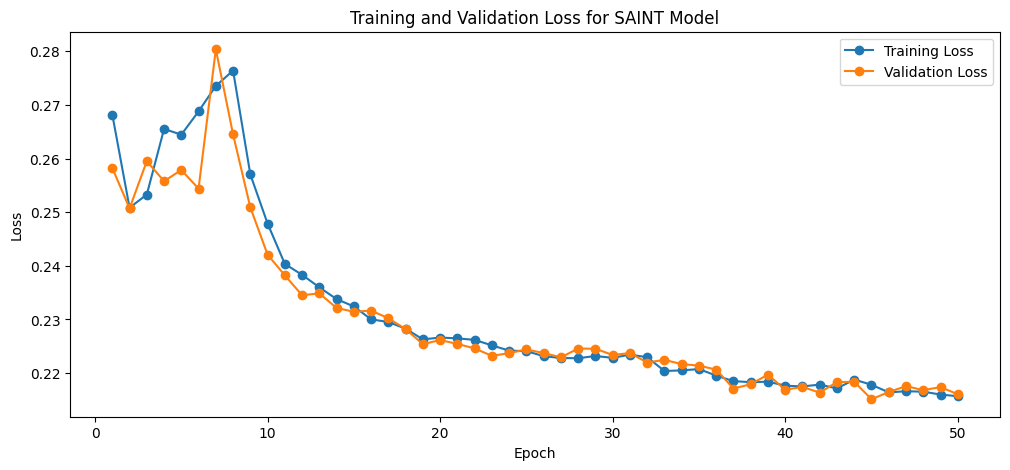

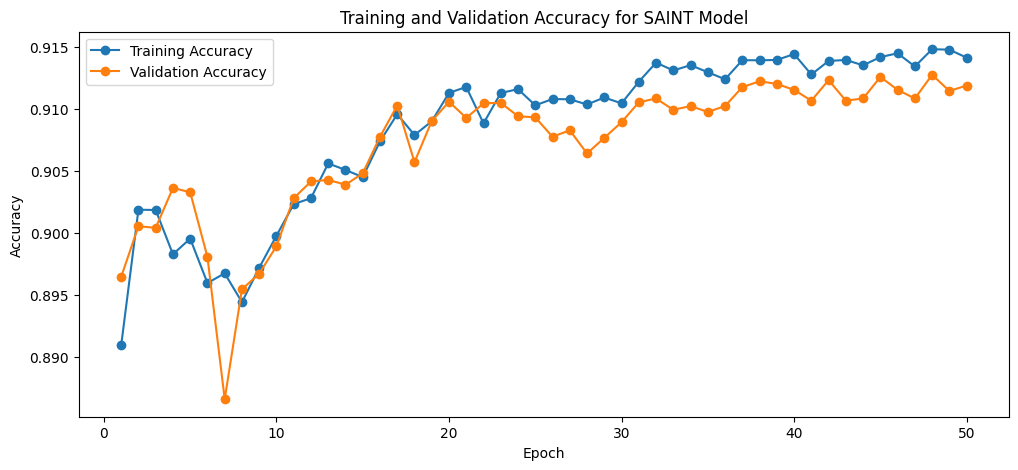

In [18]:
# Plot training and validation loss curves
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Training Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for SAINT Model')
plt.legend()
plt.savefig(os.path.join(save_directory, "loss_curve_saint.png"))
plt.show()

# Plot training and validation accuracy curves
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, marker='o', label='Training Accuracy')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for SAINT Model')
plt.legend()
plt.savefig(os.path.join(save_directory, "accuracy_curve_saint.png"))
plt.show()

In [19]:
# Set the model to evaluation mode
model.eval()

# Initialize lists to store predictions, labels, and probabilities
all_preds_saint = []
all_labels_saint = []
all_probs_saint = []

# Disable gradient computation for evaluation
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        # Forward pass: compute model output
        outputs = model(batch_x)
        
        # Compute softmax probabilities
        probs = torch.softmax(outputs, dim=1)
        
        # Get the predicted class (the one with the max probability)
        _, preds = torch.max(outputs, 1)
        
        # Store predictions, true labels, and probabilities
        all_preds_saint.extend(preds.cpu().tolist())
        all_labels_saint.extend(batch_y.cpu().tolist())
        all_probs_saint.extend(probs.cpu().tolist())

# Convert lists to PyTorch tensors
all_preds_saint = torch.tensor(all_preds_saint)
all_labels_saint = torch.tensor(all_labels_saint)
all_probs_saint = torch.tensor(all_probs_saint)

# Calculate overall accuracy
accuracy_saint = (all_preds_saint == all_labels_saint).float().mean().item()
print(f"Accuracy: {accuracy_saint:.4f}")

# Convert tensors to lists for scikit-learn metrics
y_true = all_labels_saint.tolist()
y_pred = all_preds_saint.tolist()

# Generate and print the classification report
report = classification_report(y_true, y_pred)
print("Classification Report:\n", report)

# Generate and print the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Generate and print ROC AUC score if binary classification
if output_dim == 2:
    y_true_bin = label_binarize(y_true, classes=[0, 1])
    y_prob_bin = np.array([prob[1] for prob in all_probs_saint])
    roc_auc = roc_auc_score(y_true_bin, y_prob_bin)
    print(f"ROC AUC Score: {roc_auc:.4f}")


Accuracy: 0.9125
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     19749
           1       0.87      0.87      0.87     19373
           2       0.86      0.86      0.86     18358

    accuracy                           0.91     57480
   macro avg       0.91      0.91      0.91     57480
weighted avg       0.91      0.91      0.91     57480

Confusion Matrix:
 [[19714     5    30]
 [   14 16896  2463]
 [   51  2467 15840]]


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize

def plot_confusion_matrix(model_name, conf_matrix, save_path):
    # Ensure the save_path directory exists
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    # Plot confusion matrix
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{model_name} Confusion Matrix')
    plt.savefig(os.path.join(save_path, f"{model_name}_confusion_matrix.png"))  
    plt.show()  
    plt.close()  

def plot_roc_curve(model_name, y_test, y_prob, save_path):
    # Ensure the save_path directory exists
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    # Binarize the labels for multi-class ROC AUC
    y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])
    n_classes = y_test_binarized.shape[1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    colors = ['blue', 'red', 'green']
    total_auc = 0

    # Convert y_prob from list of lists to a 2D list (list of lists)
    y_prob = [[float(prob) for prob in probs] for probs in y_prob]

    # Calculate ROC metrics and plot
    plt.figure(figsize=(10, 7))
    for i in range(n_classes):
        # Convert lists to tensors and then to numpy arrays for roc_curve
        y_test_bin = [row[i] for row in y_test_binarized]
        y_prob_class = [row[i] for row in y_prob]
        fpr[i], tpr[i], _ = roc_curve(y_test_bin, y_prob_class)
        roc_auc[i] = auc(fpr[i], tpr[i])
        total_auc += roc_auc[i]
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
                 label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

    avg_auc = total_auc / n_classes
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} Receiver Operating Characteristic (ROC)')
    plt.legend(loc='lower right')
    plt.savefig(os.path.join(save_path, f"{model_name}_roc_curve.png"))  
    plt.show()  
    plt.close() 

    return avg_auc




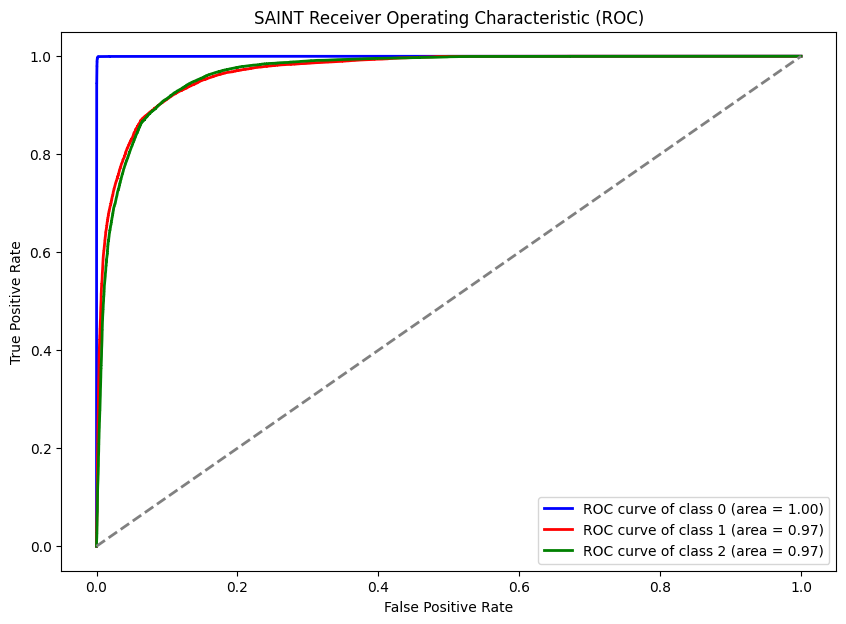

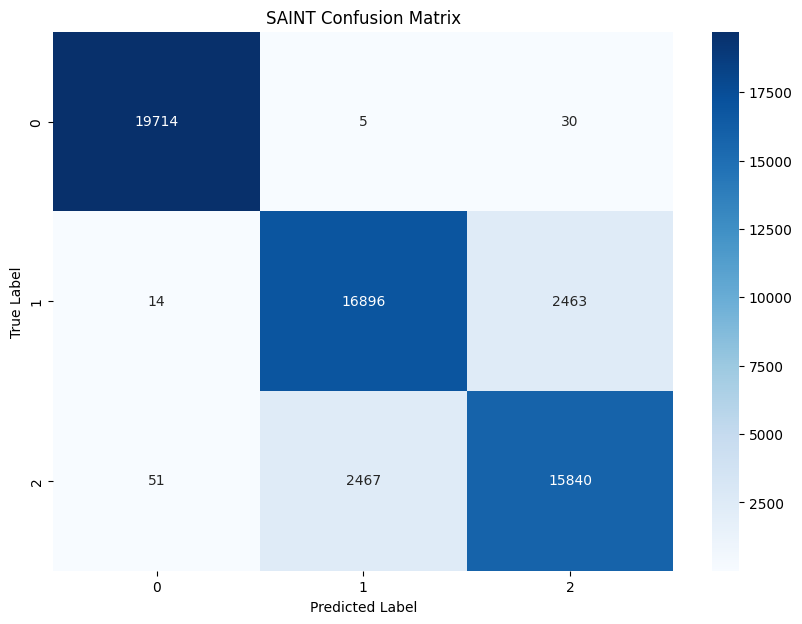

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19749
           1       0.87      0.87      0.87     19373
           2       0.86      0.86      0.86     18358

    accuracy                           0.91     57480
   macro avg       0.91      0.91      0.91     57480
weighted avg       0.91      0.91      0.91     57480

ROC AUC Score: 0.9789


In [21]:
# Evaluation for SAINT Model
model.eval()
all_preds_saint = []
all_labels_saint = []
all_probs_saint = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_preds_saint.extend(preds.cpu().tolist())
        all_labels_saint.extend(batch_y.cpu().tolist())
        all_probs_saint.extend(probs.cpu().tolist())

# Convert lists to PyTorch tensors
all_preds_saint = torch.tensor(all_preds_saint)
all_labels_saint = torch.tensor(all_labels_saint)
all_probs_saint = torch.tensor(all_probs_saint)

# Convert tensors to lists for scikit-learn metrics
y_test = all_labels_saint.tolist()
y_pred = all_preds_saint.tolist()
y_prob = [prob for prob in all_probs_saint]  # Convert to list of lists

# Compute confusion matrix
conf_matrix_saint = confusion_matrix(y_test, y_pred)

# Compute ROC AUC manually
roc_auc_saint = plot_roc_curve("SAINT", y_test, y_prob, save_directory)

# Classification report
report_saint = classification_report(y_test, y_pred)

# Plot and save the results
plot_confusion_matrix("SAINT", conf_matrix_saint, save_directory)

print(f"Classification Report:\n{report_saint}")
print(f"ROC AUC Score: {roc_auc_saint:.4f}")